<a href="https://colab.research.google.com/github/hanifahamany/buah-detection-ws/blob/main/buah_detection_ws.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation

## Google Colab GPU

In [ ]:
!nvidia-smi

Tue Sep  8 13:13:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Google Drive Connect & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip -q /content/drive/MyDrive/seleksi-ws/dataset-buah.zip -d /content/drive/MyDrive/seleksi-ws

## Setup Environment & Dependencies

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 6.1 MB/s eta 0:00:00


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.8 MB/s eta 0:00:00


In [16]:
import os
import random
import urllib.request
import numpy as np
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import drive

# Training

In [ ]:
from ultralytics import YOLO
import os

def main():
    model = YOLO("yolov8n.pt")

    yaml_path = "/content/drive/MyDrive/seleksi-ws/dataset-buah/data.yaml"

    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f"data.yaml is not found: {yaml_path}")

    print("start training...")

    model.train(
        data=yaml_path,
        epochs=25,
        imgsz=640,
        project="/content/drive/MyDrive/seleksi-ws/dataset-buah/runs/detect",
        name="buah_model",
        exist_ok=True,
    )

    print("finished")
    print("model tersimpan di /content/drive/MyDrive/seleksi-ws/dataset-buah/runs/detect/buah_model/weights/best.pt")

if __name__ == '__main__':
    main()

start training...
Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/seleksi-ws/dataset-buah/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bua

# Inference

detecting...

0: 640x640 1 Apple, 7.2ms
Speed: 1.1ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


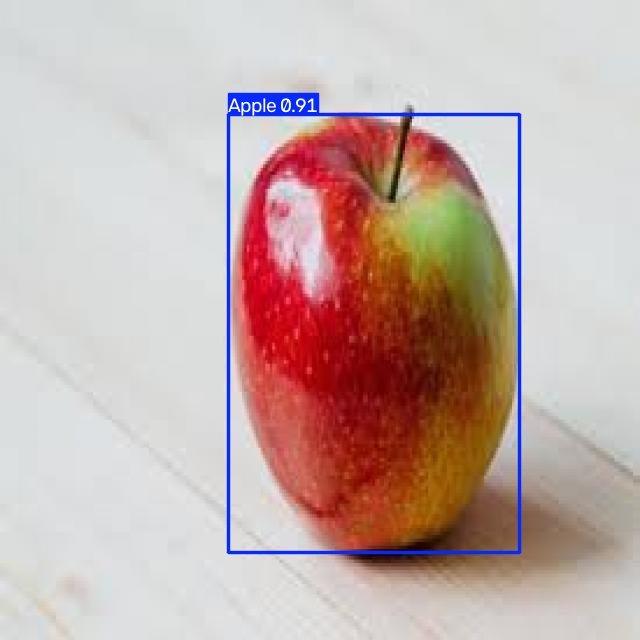

In [15]:
# Inference Path Manual Dari Google Drive

# load model
model_path = "/content/drive/MyDrive/seleksi-ws/dataset-buah/runs/detect/buah_model/weights/best.pt"

# path gambar manual
image_path = "/content/drive/MyDrive/seleksi-ws/dataset-buah/test/images/images-28-_jpeg.rf.5a1a4d2f17f29bbc02c8e7b28f235447.jpg"

if not os.path.exists(model_path):
    print(f"error: model tidak ditemukan di {model_path}")
elif not os.path.exists(image_path):
    print(f"error: gambar tidak ditemukan di {image_path}")
else:
    model = YOLO(model_path)
    img = cv2.imread(image_path)

    if img is None:
        print("error: file ditemukan tapi gagal dibaca (kemungkinan file rusak atau bukan format gambar).")
    else:
        print("detecting...")
        results = model.predict(source=img, conf=0.5)
        annotated_frame = results[0].plot()
        cv2_imshow(annotated_frame)

gambar yang diuji: /content/drive/MyDrive/seleksi-ws/dataset-buah/test/images/Image_20_jpg.rf.b76a31139cb3f4f25f238f2d88bfc793.jpg
detecting...

0: 640x640 3 Mangos, 7.3ms
Speed: 107.0ms preprocess, 7.3ms inference, 44.2ms postprocess per image at shape (1, 3, 640, 640)


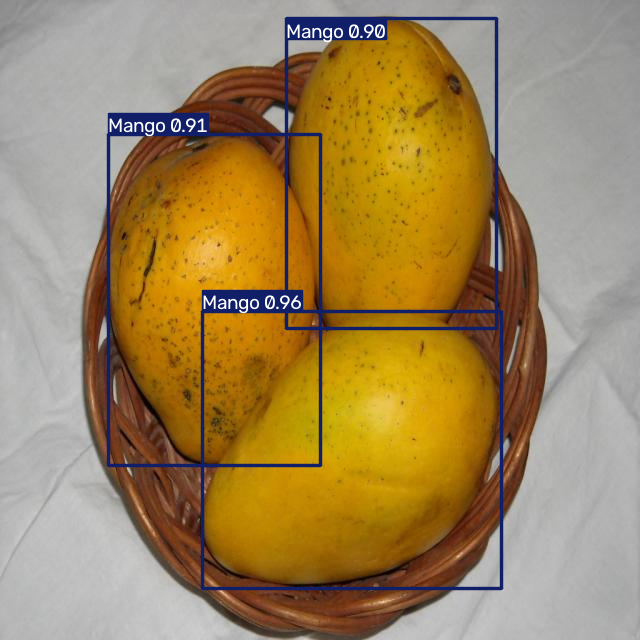

In [4]:
# Inference Random Pick Dari Google Drive

model_path = "/content/drive/MyDrive/seleksi-ws/dataset-buah/runs/detect/buah_model/weights/best.pt"
model = YOLO(model_path)

# random pick dr folder test
folder_path = "/content/drive/MyDrive/seleksi-ws/dataset-buah/test/images"
daftar_file = os.listdir(folder_path)
file_acak = random.choice(daftar_file)
image_path = os.path.join(folder_path, file_acak)

print(f"gambar yang diuji: {image_path}")

img = cv2.imread(image_path)

if img is None:
    print("error: image not found.")
else:
    print("detecting...")
    results = model.predict(source=img, conf=0.5)

    annotated_frame = results[0].plot()

    cv2_imshow(annotated_frame)

detecting...

0: 640x640 3 Watermelons, 7.2ms
Speed: 4.4ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


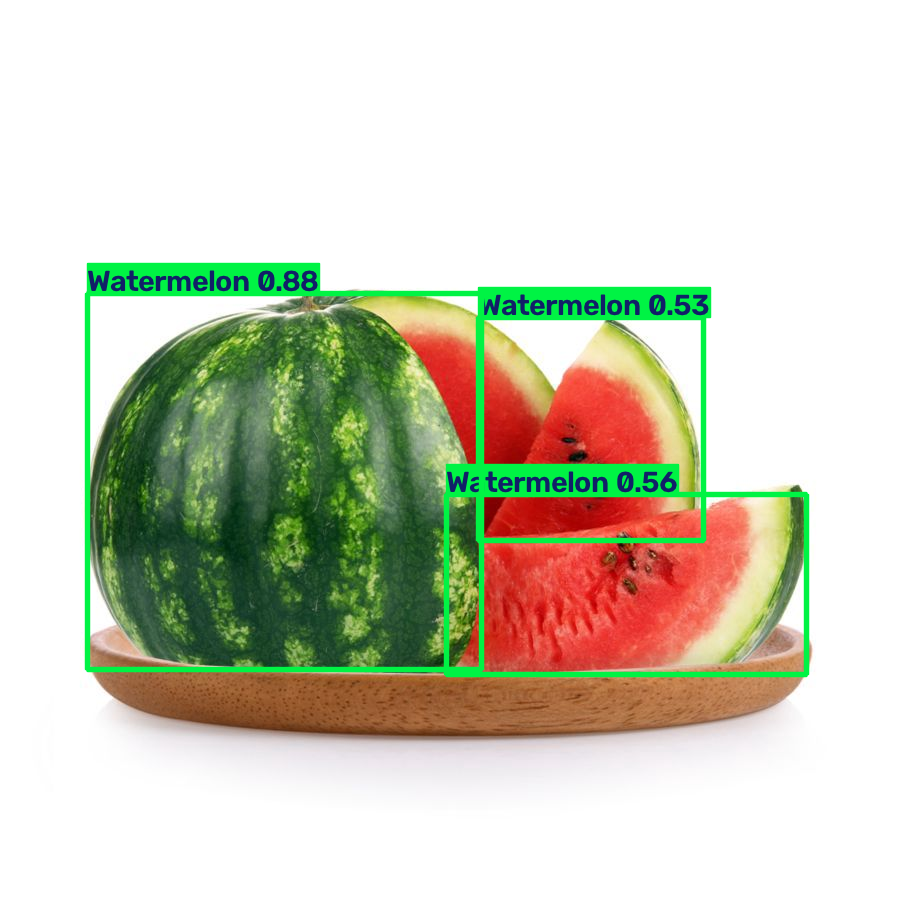

In [19]:
# Inference Dari Link Eksternal

model_path = "/content/drive/MyDrive/seleksi-ws/dataset-buah/runs/detect/buah_model/weights/best.pt"

# link
image_url = "https://image.astronauts.cloud/product-images/2026/7/1Cover20240515T14293_ec74a6c3-7bb0-42da-bbe6-e694c4f10515_900x900.jpg"

if not os.path.exists(model_path):
    print(f"error: model tidak ditemukan di {model_path}")
else:
    model = YOLO(model_path)

    try:
        resp = urllib.request.urlopen(image_url)
        image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
        img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    except Exception as e:
        print(f"error: gagal mengunduh atau membaca gambar dari url: {e}")
        img = None

    if img is None:
        print("error: image not found or invalid.")
    else:
        print("detecting...")
        results = model.predict(source=img, conf=0.5)
        annotated_frame = results[0].plot()
        cv2_imshow(annotated_frame)